The goal is to explore the information related to the object keys, and their native associated file structure.

In [1]:
# Initialize notebook
import sys

from pathlib import Path
sys.path.insert(0, Path("../..").resolve().absolute().__str__() )

from xaidar.filesUtils import loadPickle

In [2]:
pd_rawSizesdir = Path( "../../../data/s3Sizes/pandda/raw")
xc_rawSizesdir = Path( "../../../data/s3Sizes/xchem/raw")

## Look at File Structure Associated to Object Keys

### Look at Sample of Object Keys Interactively

###  - Bucket: PanDDA

In [492]:
# Get a list of fragments
lst_fragFiles = [file for file in  pd_rawSizesdir.iterdir() if file.is_file() ]

In [493]:
fragIdx = 0
fragFile = loadPickle( lst_fragFiles[fragIdx])

In [494]:
sampleIdx = 0

In [661]:
sampleSize = 10

for objKey in list( fragFile.keys() )[ sampleIdx*sampleSize : (sampleIdx+1)*sampleSize ]:
    print( objKey)
sampleIdx += 100
# sampleIdx = sampleIdx - 100*5

DAPD/shells/2.4176321837953445/log.json
DAPD/processed_datasets/DAPD-x0726/1/rhofit/Hit_00_00_004.pdb
DAPD/shells/2.2676321837953446/log.json
DAPD/shells/2.3676321837953447/log.json
DAPD/shells/2.567632183795345/log.json
DAPD/shells/2.517632183795345/log.json
DAPD/processed_datasets/DAPD-x0727/2/log.json
DAPD/processed_datasets/DAPD-x0727/1/scores.json
DAPD/shells/2.717632183795345/log.json
DAPD/processed_datasets/DAPD-x0727/1/cut.ccp4


In [597]:
fragIdx += 1
fragFile = loadPickle( lst_fragFiles[fragIdx])
sampleIdx = 0

###  - Bucket: xchem

In [662]:
# Get a list of fragments
lst_fragFiles = [file for file in  xc_rawSizesdir.iterdir() if file.is_file() ]

In [663]:
fragIdx = 0
fragFile = loadPickle( lst_fragFiles[fragIdx])

In [665]:
sampleIdx = 0

In [669]:
sampleSize = 10

for objKey in list( fragFile.keys() )[ sampleIdx*sampleSize : (sampleIdx+1)*sampleSize ]:
    print( objKey)
sampleIdx += 100
# sampleIdx = sampleIdx - 100*5

data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1071/DCP2B-x1071_1_/fast_dp/forkintegrate_array_job.po18261547.4
data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1079/DCP2B-x1079_1_/xia2/dials-runP212121/xia2-working.phil
data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1070/DCP2B-x1070_1_/xia2/dials-runP212121/automatic.xinfo
data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1071/DCP2B-x1071_1_/fast_ep/P212121/7/2.5/sad_fa.pdb
data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1069/DCP2B-x1069_2_/multi-xia2/dialsP212121/LogFiles/AUTOMATIC_DEFAULT_pointless.log
data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1069/DCP2B-x1069_1_/fast_ep/P21221/1/3.0/sad_fa.hkl
data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1092/DCP2B-x1092_1_/xia2/dials-run/xia2-working.phil
data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1069/D

In [ ]:
fragIdx += 1
fragFile = loadPickle( lst_fragFiles[fragIdx])
sampleIdx = 0

### - xchem : Dataset

In [10]:
fragFile = loadPickle( xc_rawSizesdir / "frag14_sizes.pkl")

In [ ]:
sampleSize = 10
sampleIdx = 9294500// sampleSize

In [ ]:


for objKey in list( fragFile.keys() )[ sampleIdx*sampleSize : (sampleIdx+1)*sampleSize ]:
    print( objKey)
sampleIdx += 10 * sampleSize
# sampleIdx = sampleIdx - 100*5

data/lb30852/lb30852-1/processing/lab36/ispyb/lb30852-1_2022-05-10_15-56-19_ispyb.csv
data/lb32627/lb32627-1/processing/lab36/sqlite3.dll
data/lb32627/lb32627-1/processing/lab36/SQLite3_StdCall.dll
dataset/autoprocessing/70X/70X-x0049/70X-x0049.free.mtz
data/lb30852/lb30852-1/processing/database/DataFileBackups/soakDBDataFile_20220512110714.sqlite
dataset/autoprocessing/70X/70X-x0053/70X-x0053.log
dataset/autoprocessing/70X/70X-x0052/70X-x0052.free.mtz
dataset/autoprocessing/70X/70X-x0051/70X-x0051.log
data/lb30852/lb30852-1/processing/database/DataFileBackups/soakDBDataFile_20220512110749.sqlite
dataset/autoprocessing/70X/70X-x0055/70X-x0055.log


### Get Name of Folders for the first 3 levels of the File System

In [671]:
bucketDirs = [pd_rawSizesdir, xc_rawSizesdir ]
bucketNames = ["pandda", "xchem"]
storeFolderNames = { dir: { "1stLevel" : set(), "2ndLevel" : set(), "3rdLevel" : set() } for dir in bucketNames }


for bucketDir, bucket in zip( bucketDirs, bucketNames ):
    for fragFilePath in bucketDir.iterdir():
        if fragFilePath.is_file():
            frag = loadPickle( fragFilePath )
            for objKey in frag.keys():
                objPath = objKey.split("/")
                storeFolderNames[bucket]["1stLevel"].add( objPath[0])
                if len(objPath) >= 2: storeFolderNames[bucket]["2ndLevel"].add(objPath[1])
                if len(objPath) >= 3: storeFolderNames[bucket]["3rdLevel"].add( objPath[2] )

In [673]:
for dir, values in storeFolderNames.items():
    print( f"List of Directories found in {dir} Bucket for:")
    for level, list in values.items():
        print( f"\t{level} - {sorted(list)}")
    print("\n")

List of Directories found in pandda Bucket for:
	1stLevel - ['70X', '70X.err', '70X.log', '70X.out', '70X.sh', '70X.singularity.sh', 'AAVNAR', 'AAVNAR.err', 'AAVNAR.log', 'AAVNAR.out', 'AAVNAR.sh', 'AAVNAR.singularity.sh', 'AA_VNAR_XF01', 'AA_VNAR_XF01.err', 'AA_VNAR_XF01.log', 'AA_VNAR_XF01.out', 'AA_VNAR_XF01.sh', 'AA_VNAR_XF01.singularity.sh', 'ACVR1A', 'ACVR1A.err', 'ACVR1A.log', 'ACVR1A.out', 'ACVR1A.sh', 'ACVR1A.singularity.sh', 'ATAD2A', 'ATAD2A.err', 'ATAD2A.log', 'ATAD2A.out', 'ATAD2A.sh', 'ATAD2A.singularity.sh', 'B2m', 'B2m.err', 'B2m.log', 'B2m.out', 'B2m.sh', 'B2m.singularity.sh', 'BKVP1', 'BKVP1.err', 'BKVP1.log', 'BKVP1.out', 'BKVP1.sh', 'BKVP1.singularity.sh', 'BKVP126', 'BKVP126.err', 'BKVP126.log', 'BKVP126.out', 'BKVP126.sh', 'BKVP126.singularity.sh', 'BRD1', 'BRD1.err', 'BRD1.log', 'BRD1.out', 'BRD1.sh', 'BRD1.singularity.sh', 'CD44MMA', 'CD44MMA.err', 'CD44MMA.log', 'CD44MMA.out', 'CD44MMA.sh', 'CD44MMA.singularity.sh', 'CD73', 'CD73.err', 'CD73.log', 'CD73.out', '

---

### Total pandda files

In [2]:
# Check if there are no errors during the file type sizes processing
import re
pd_rawKeysdir = Path( "../../../data/s3ObjKeys/pandda/raw")
pd_rawSizesdir = Path( "../../../data/s3Sizes/pandda/raw")


def count( datadir, countFunction, filterFunction= lambda x: True):
    filesCount = 0
    for file in datadir.iterdir():
        if file.is_file() and filterFunction(file):
            temp = loadPickle(file)
            filesCount += countFunction(temp)
    return filesCount

pd_rawKeyscount = count(pd_rawKeysdir, lambda x: len(x["Content"][1:]))
pd_rawSizescount = count(pd_rawSizesdir, lambda x: len(x.keys()))

print(f"Total Object Key files in pandda: {pd_rawKeyscount}")
print(f"Total Object Size files in pandda: {pd_rawSizescount}")


Total Object Key files in pandda: 5115662
Total Object Size files in pandda: 5115662


## Total xchem files

In [5]:
import re
xc_rawKeysdir = Path( "../../../data/s3ObjKeys/xchem/raw")
xc_rawSizesdir = Path( "../../../data/s3Sizes/xchem/raw")


def count( datadir, countFunction, filterFunction= lambda x: True):
    filesCount = 0
    for file in datadir.iterdir():
        if file.is_file() and filterFunction(file):
            temp = loadPickle(file)
            filesCount += countFunction(temp)
    return filesCount

# xc_rawKeyscount = count(xc_rawKeysdir, lambda x: len(x["Content"][1:]))
xc_rawSizescount = count(xc_rawSizesdir, lambda x: len(x.keys()))

# print(f"Total Object Key files in xchem: {xc_rawKeyscount}")
print(f"Total Object Size files in xchem: {xc_rawSizescount}")

Total Object Size files in xchem: 129663907


## Look at Root directories in Each Bucket

In [7]:
xchemRawKeysDir = Path("../../../data/s3ObjKeys/xchem/raw").resolve()
panddaRawKeysDir = Path("../../../data/s3ObjKeys/pandda/raw").resolve()

In [ ]:
import re
lstRawKeysDir = [panddaRawKeysDir, xchemRawKeysDir]

rootNames = {"pandda": set(), "xchem": set() }
for dir, bucketName in zip( lstRawKeysDir, ["pandda", "xchem"] ):
    for fragPath in dir.iterdir():
        if fragPath.is_file():
            frag = loadPickle( fragPath )
            stRoots = set( [ path.split("/")[0] for path in frag["Content"][1:] if not re.search( "\.", path.split("/")[0]) ])
            rootNames[bucketName].update( stRoots)


            # print( sorted(list(stRoots)[:5]))
            # print( type( frag))
            # print( type( frag["Content"]))
            # print(  frag["Content"][:50])

    #         break
    # break
            

In [33]:
print( sorted(list(rootNames["pandda"]))[:100])
print( sorted(list(rootNames["xchem"]))[:100])

['70X', 'AAVNAR', 'AA_VNAR_XF01', 'ACVR1A', 'ATAD2A', 'B2m', 'BKVP1', 'BKVP126', 'BRD1', 'CD44MMA', 'CD73', 'CD73mp', 'CYCK', 'DAPD', 'DCLRE1AA', 'DCP2B', 'EBNA_A2', 'EBNA_T2', 'ERAP1', 'FALZA', 'FabF_C164Q', 'G13D', 'G7', 'GALE', 'GN6S', 'GluN1N2A', 'HAO1A', 'HARBD', 'HEC1', 'HPrP', 'HSP90', 'IAV', 'IDH1', 'JMJD1BA', 'JMJD2AA', 'JMJD2DA', 'JOELS', 'KAT2B', 'KLHL7B', 'KdsA', 'LC_TbrB1', 'LchARH3', 'LmARS', 'M2', 'MACROD1A', 'MID2A', 'MUREECA', 'Mpro', 'NS3Hel', 'NSP15', 'NSP15_B', 'NSP16', 'NUDT21A', 'NUDT22A', 'NUDT4A', 'NUDT5A', 'NUDT7A', 'Nprot', 'OTUB2A', 'OXA10OTA', 'PARG', 'PDE5', 'PDK2', 'PGN_RS02895PGA', 'PHD2', 'PHIPA', 'PIF1', 'PKL1', 'PKM1', 'PP1', 'PRPB', 'PTP1B', 'PWWP_C64S', 'PaFEN_D4', 'PaPBP3', 'PlProwt', 'RECQL5', 'RECQL5A', 'RabC01', 'SETDB1', 'SHH', 'SHMT2A', 'SOCS2A', 'STAG1A', 'TBRUFPPS', 'TBXTA', 'TCRUFPPS', 'TMEMAB', 'TNCA', 'TRF1', 'TRIM2A', 'TbMDO', 'TbrB1', 'TcHRS', 'VP30ctd', 'XX02KALRNA', 'XX11RECQL5A', 'a7ACHBPm', 'mArh', 'macro']
['data', 'dataset']


In [72]:
frag = loadPickle( panddaRawKeysDir / "frag14.pkl")

panddaContent= {"level2": set(), "level3": set()}
print("pandda bucket example keys:")
for fragPath in panddaRawKeysDir.iterdir():
    frag = loadPickle( fragPath)
    idx = 0
    for key in frag["Content"][1:]:
        if len(key.split("/") ) >= 2: panddaContent["level2"].add( key.split("/")[1])
        if len(key.split("/") ) >= 3:panddaContent["level3"].add( key.split("/")[2])
        if idx <= 2:
            print("\t", key)
            idx +=1
        else: pass

pandda bucket example keys:
	 70X.err
	 70X.log
	 70X.out
	 DAPD/processed_datasets/DAPD-x0029/7/rhofit/Hit_00_00_003.pdb
	 DAPD/processed_datasets/DAPD-x0029/7/rhofit/Hit_00_00_004.pdb
	 DAPD/processed_datasets/DAPD-x0029/7/rhofit/Hit_00_00_005.pdb
	 DAPD/processed_datasets/DAPD-x0531/14/rhofit.lis
	 DAPD/processed_datasets/DAPD-x0531/14/rhofit/Hit_00_00_000.pdb
	 DAPD/processed_datasets/DAPD-x0531/14/rhofit/Hit_00_00_001.pdb
	 DCP2B/processed_datasets/DCP2B-x0369/ligand_files/FMOPL000050a_TMP/mol_1_conf_20_tmp_init.pdb
	 DCP2B/processed_datasets/DCP2B-x0369/ligand_files/FMOPL000050a_TMP/mol_1_conf_20_tmp_refmac_stage_0.log
	 DCP2B/processed_datasets/DCP2B-x0369/ligand_files/FMOPL000050a_TMP/mol_1_conf_20_tmp_refmac_stage_0.pdb
	 EBNA_T2/processed_datasets/EBNA_T2-x0169/1/scores.json
	 EBNA_T2/processed_datasets/EBNA_T2-x0169/1/truncated.ccp4
	 EBNA_T2/processed_datasets/EBNA_T2-x0169/2/ana_pdbmaps.log
	 FabF_C164Q/processed_datasets/FabF_C164Q-x0427/2/scores.json
	 FabF_C164Q/process

In [75]:
lev1, lev2, lev3 = sorted(list(rootNames["pandda"]))[:], panddaContent["level2"], panddaContent["level3"]
print( f"First Level Contents: { lev1}")
print( f"Second Level Contents: { lev2 }")
print( f"Third Level Contents: { lev3}")

First Level Contents: ['70X', 'AAVNAR', 'AA_VNAR_XF01', 'ACVR1A', 'ATAD2A', 'B2m', 'BKVP1', 'BKVP126', 'BRD1', 'CD44MMA', 'CD73', 'CD73mp', 'CYCK', 'DAPD', 'DCLRE1AA', 'DCP2B', 'EBNA_A2', 'EBNA_T2', 'ERAP1', 'FALZA', 'FabF_C164Q', 'G13D', 'G7', 'GALE', 'GN6S', 'GluN1N2A', 'HAO1A', 'HARBD', 'HEC1', 'HPrP', 'HSP90', 'IAV', 'IDH1', 'JMJD1BA', 'JMJD2AA', 'JMJD2DA', 'JOELS', 'KAT2B', 'KLHL7B', 'KdsA', 'LC_TbrB1', 'LchARH3', 'LmARS', 'M2', 'MACROD1A', 'MID2A', 'MUREECA', 'Mpro', 'NS3Hel', 'NSP15', 'NSP15_B', 'NSP16', 'NUDT21A', 'NUDT22A', 'NUDT4A', 'NUDT5A', 'NUDT7A', 'Nprot', 'OTUB2A', 'OXA10OTA', 'PARG', 'PDE5', 'PDK2', 'PGN_RS02895PGA', 'PHD2', 'PHIPA', 'PIF1', 'PKL1', 'PKM1', 'PP1', 'PRPB', 'PTP1B', 'PWWP_C64S', 'PaFEN_D4', 'PaPBP3', 'PlProwt', 'RECQL5', 'RECQL5A', 'RabC01', 'SETDB1', 'SHH', 'SHMT2A', 'SOCS2A', 'STAG1A', 'TBRUFPPS', 'TBXTA', 'TCRUFPPS', 'TMEMAB', 'TNCA', 'TRF1', 'TRIM2A', 'TbMDO', 'TbrB1', 'TcHRS', 'VP30ctd', 'XX02KALRNA', 'XX11RECQL5A', 'a7ACHBPm', 'mArh', 'macro', 'mac

In [60]:
lookExample = True
datasetContent = {"level2":set(), "level3":set()}
frag = loadPickle( xchemRawKeysDir / "frag14.pkl")
for key in frag["Content"]:
    if key[:7] == "dataset":
        datasetContent["level2"].add( key.split("/")[1] )
        datasetContent["level3"].add( key.split("/")[2])
        if lookExample:
            print(f"Example of dataset key:{key}")
            lookExample = False

print(  datasetContent["level2"])
# print( type( frag["Content"][-10][:7]) )

Example of dataset key:dataset/autoprocessing/70X/70X-x0049/70X-x0049.free.mtz
{'dimple', 'autoprocessing'}


In [59]:
print(  sorted(datasetContent["level3"]))
lenDataset, lenPandda = len(datasetContent["level3"]), len(rootNames["pandda"]) 
print( f"Dataset Number of datasets: { lenDataset }")
print( f"Pandda Number of datasets: {lenPandda}")

if datasetContent["level3"] == rootNames["pandda"]:
    print( "xchem dataset contains the same datasets as pandda bucket")
if datasetContent["level3"] != rootNames["pandda"]:
    print( "xchem dataset with NOT the same datasets as pandda")

matchDatasets = rootNames["pandda"] & datasetContent["level3"]
panddaMismatch = rootNames["pandda"] - matchDatasets
xchemDatasetMismatch = datasetContent["level3"]  - matchDatasets
numbMatchingDatasets = len( matchDatasets ) 
if numbMatchingDatasets == 103:
    print( "All pandda datasets exist in dataset")
else:
    print( f"Number of matched: {numbMatchingDatasets}")
    print( "Matched Datasets: ", sorted(matchDatasets) )
    print( f"Pandda missmatched Datasets: {len(panddaMismatch)} - {sorted(panddaMismatch) }")
    print( f"Xchem dataset missmatched Datasets: {len(xchemDatasetMismatch)} - {sorted(xchemDatasetMismatch) }")

['70X', 'AASSA', 'AAVNAR', 'AAVNAR-XF01', 'AA_VNAR_XF01', 'ACVR1A', 'ADARB1A', 'ALAS2A', 'ALDH7A1A', 'APBE', 'ATAD2A', 'B2m', 'BC1960', 'BKVP1', 'BKVP126', 'BRD1', 'BRD4', 'CAMK1DA', 'CD44MMA', 'CD73', 'CD73mp', 'CD73p', 'CYCK', 'CtUTTG_GT24', 'CycT2', 'DAPD', 'DBDJBP1', 'DCLRE1AA', 'DCP2B', 'DHTKD1A', 'EBNA_A', 'EBNA_A2', 'EBNA_T', 'EBNA_T2', 'ECR', 'EPB41L3A', 'ERAP1', 'FALZA', 'FAM83BA', 'FIH', 'FabF_C164Q', 'G13D', 'GALE', 'GALK1A', 'GN6S', 'HAO1A', 'HARBD', 'HDAC6', 'HEC1', 'HERC2A', 'HPrP', 'HSET', 'HSP90', 'IAV-3P', 'IDH1', 'IMPA1A', 'INPP5DA', 'IRF4', 'JARID1BA', 'JMJD2AA', 'JOELS', 'KAT2B', 'KBTBD5A', 'KLHL7B', 'KPNF', 'KdsA', 'LC_TbrB1', 'LchARH3', 'LmARS', 'M2-1', 'MACROD1A', 'MID2A', 'MMGLU2', 'MPRO', 'MUREECA', 'Mac1', 'Mac1-Nuc', 'MerA', 'MmGluIITryps', 'Mpro', 'Mpro_Nterm', 'NS3Hel', 'NSP14', 'NSP15', 'NSP15_B', 'NSP16', 'NUDT21A', 'NUDT22A', 'NUDT4A', 'NUDT5A', 'NUDT7A', 'NUDT7A_CR_SL', 'NUDT7A_Crude', 'NUDT7_mpin', 'Nprot', 'OTUB2A', 'OXA10', 'OXA10OTA', 'PARG', 'PARP1

In [39]:
for fragPath in xchemRawKeysDir.iterdir():
    frag = loadPickle( fragPath)
    for key in frag["Content"][1:]:
        print(key[:7])
        break
        if key[:7] == "dataset":
            print(key)  
            break
    



data/20
data/20


KeyboardInterrupt: 

## Looking At Sessions

In [ ]:
# Get a List of Paths to Directories with Sessions Synthax -> st_sessions.pkl

from xaidar.filesUtils import loadPickle, savePyObj
import re


rawXCDir = Path( "../../../data/s3ObjKeys/xchem/raw")

sessionRegex = "^[a-z][a-z][0-9]+-[0-9]+$"
lstSessionDirs = set()

for fragFile in rawXCDir.iterdir():
    if fragFile.is_file():
        print( f"Loading file: {fragFile.name}")
        frag = loadPickle( fragFile)
        keys = frag["Content"][1:]
        for objKey in keys:
            pathLst = objKey.split("/")
            path = ""
            for item in pathLst:
                path += "/" + item
                if re.search( sessionRegex, item):
                    lstSessionDirs.add( path[1:] )

savePyObj( lstSessionDirs, Path( "./lst_sessions.pkl"))

In [ ]:
# checking for sessions without canonical synthax
import re
rawXCDir = Path( "../../../data/s3ObjKeys/xchem/raw")

sessionRegex = "^[a-z][a-z][0-9]+-[0-9]+$"

lstWeirdSeshNames = set()

for fragFile in rawXCDir.iterdir():
    if fragFile.is_file():
        print( f"Loading file: {fragFile.name}")
        frag = loadPickle( fragFile)
        keys = frag["Content"][1:]
        for objKey in keys:
            session = objKey.split("/")[2]
            if not re.search( sessionRegex, session):
                lstWeirdSeshNames.add( session )

Loading file: frag1.pkl
Loading file: frag10.pkl
Loading file: frag11.pkl
Loading file: frag12.pkl
Loading file: frag13.pkl
Loading file: frag14.pkl
Loading file: frag2.pkl
Loading file: frag3.pkl
Loading file: frag4.pkl
Loading file: frag5.pkl
Loading file: frag6.pkl
Loading file: frag7.pkl
Loading file: frag8.pkl
Loading file: frag9.pkl


In [57]:
print( len( lstWeirdSeshNames))
print( lstWeirdSeshNames)

164
{'APBE', 'TRIM2A', 'IMPA1A', 'USP8A', 'Vim2', 'STAG1A', 'ACVR1A', 'KAT2B', 'CAMK1DA', 'MMGLU2', 'B2m', 'zkmt', 'EBNA_A', 'MACROD1A', 'TRIM16A', 'MmGluIITryps', 'OXA10', 'SOCS2A', 'PBP5', 'PlProwt', 'TBXTA', 'NUDT7_mpin', 'BKVP126', 'PARP14A', 'FIH', 'VP30ctd', '70X', 'DCP2B', 'TbTR', 'PWWP_C64S', 'NSP14', 'TRF1', 'AA_VNAR_XF01', 'ADARB1A', 'EBNA_T', 'MerA', 'NSP15_B', 'AASSA', 'CYCK', 'FALZA', 'TbrB1', 'R1', 'BKVP1', 'PaPBP3', 'NSP16', 'macro_EU', 'ECR', 'macro-thionuc', 'gluk1', 'RECQL5', 'HEC1', 'Tif6', 'VIM2', 'LC_TbrB1', 'PTP1B', 'HDAC6', 'HERC2A', 'MUREECA', 'ALAS2A', 'IAV-3P', 'MID2A', 'PP1', 'KPNF', 'BRD1', 'NUDT7A_Crude', 'RecQ1', 'PHIPA', 'NUDT7A', 'DBDJBP1', 'CD73p', 'CD73', 'IRF4', 'RecQ1_DNA', 'RECQL5A', 'JMJD2AA', 'DCLRE1AA', 'Mpro', 'ERAP1', 'mkeap1', 'NSP15', 'NS3Hel', 'XX02KALRNA', 'RBBP7A', 'PKM1', 'YEATS4A', 'INPP5DA', 'DHTKD1A', 'Nprot', 'NUDT22A', 'srta', 'PaFEN_D4', 'TRIM25PS', 'NUDT5A', 'macro-combi', 'FAM83BA', 'AAVNAR-XF01', 'TDP2', 'Mac1-Nuc', 'ALDH7A1A', '

In [9]:
# Load Sessions Librart
from xaidar.filesUtils import loadPickle
lstSessionDirs = loadPickle( Path( "./lst_sessions.pkl"))
lstSessionDirs = sorted( list(lstSessionDirs))

In [61]:
# Select Normal Sessions (data/{year}/{lbxxx-x} or data/{year}/{lbxxx-x}/ )

# Get a list of paths split into elements of a list
lst_lstSessions = [ path.split("/") for path in lstSessionDirs if len(path.split("/")) <= 5 ]
print( f"Number of Normal Sessions: {len(lst_lstSessions ) }")
lst_lstSessions 

# Look at sessions with Subsessions
print("")
seshWsesh = [ path[2] for path in lst_lstSessions if len(path) == 5  ]
subSeshs = [ path[-1] for path in lst_lstSessions if len(path) == 5  ]
seshWseshDict = { sesh: [ path[-1] for path in lst_lstSessions if path[2] == sesh] for sesh in seshWsesh }
print( subSeshs)
print( f"Sessions with Subsession:")
for key, value in seshWseshDict.items(): print( "\t",key, value)

# Get only names rather than paths for Sessions
lst_SeshNames = [ path[-1] for path in lst_lstSessions ]
set_SeshNames = set( lst_SeshNames)
# print( "Session Names:")
# for name in lst_SeshNames: print( f"\t{name}")
print("")
print( f"There are no repeating session names between years: { sorted(list(set(lst_SeshNames)) )== sorted(lst_SeshNames)}")
print( f"Length of Set: {len( list(set( lst_SeshNames)))}")
print( f"Length of List: {len(lst_SeshNames)}")
print( f"Content of lst_SeshNames: {lst_SeshNames[:2]}" )

Number of Normal Sessions: 750

['lb13320-15', 'lb13320-17', 'lb13320-18', 'lb13320-2', 'lb13320-4', 'lb13320-7', 'lb13320-9', 'nt11175-118', 'lb13385-112', 'lb25874-11', 'lb25874-8']
Sessions with Subsession:
	 lb13320-1 ['lb13320-1', 'lb13320-15', 'lb13320-17', 'lb13320-18', 'lb13320-2', 'lb13320-4', 'lb13320-7', 'lb13320-9']
	 lb13385-1 ['lb13385-1', 'nt11175-118']
	 lb13385-64 ['lb13385-64', 'lb13385-112']
	 lb25874-6 ['lb25874-6', 'lb25874-11', 'lb25874-8']

There are no repeating session names between years: True
Length of Set: 750
Length of List: 750
Content of lst_SeshNames: ['lb13308-1', 'lb13308-2']


In [11]:
sizesDir = Path( "../../../data/s3Sizes/xchem/raw")
testFilePath = [ item for item in sizesDir.iterdir() if item.is_file() ][0]
fragFile = loadPickle( testFilePath)

In [13]:
print( type(fragFile) )
print( len(list(fragFile.keys())) )
print(list(fragFile.keys())[:5] )
print(list(fragFile.values())[:5] )

<class 'dict'>
10000976
['data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1069/DCP2B-x1069_2_/fast_ep/P2212/3/2.3/sad_fa.res', 'data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1085/DCP2B-x1085_1_/autoPROC/ap-run/aimless_late.log', 'data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1069/DCP2B-x1069_2_/multi-xia2/3diiP212121/LogFiles/AUTOMATIC_DEFAULT_aimless.html', 'data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1069/DCP2B-x1069_1_/fast_ep/P2122/1/3.0/sad_fa.pdb', 'data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1093/DCP2B-x1093_1_/fast_dp/INTEGRATE.HKL']
[498, 142179, 1405197, 429, 260856]


In [88]:
sizesDir = Path( "../../../data/s3Sizes/xchem/raw")

sizesDict = { key : [] for key in lst_SeshNames }
seshWsesh_set = set(seshWsesh)
subSeshs_set = set( subSeshs)

for fragFile in list(sizesDir.iterdir()):
    if fragFile.is_file():
        print( f"Loading file: {fragFile.name}")
        frag = loadPickle( fragFile)

        for objKey, size in frag.items():
            pathLst = objKey.split("/")
            session = pathLst[2]
            if session in set_SeshNames:     
                sizesDict[session].append(size)
                if session in seshWsesh_set:
                    subsession = pathLst[4]
                    if subsession in subSeshs_set:
                        sizesDict[subsession].append(size)


Loading file: frag10_sizes.pkl
Loading file: frag11_sizes.pkl
Loading file: frag12_sizes.pkl
Loading file: frag13_sizes.pkl
Loading file: frag14_sizes.pkl
Loading file: frag1_sizes.pkl
Loading file: frag2_sizes.pkl
Loading file: frag3_sizes.pkl
Loading file: frag4_sizes.pkl
Loading file: frag5_sizes.pkl
Loading file: frag6_sizes.pkl
Loading file: frag7_sizes.pkl
Loading file: frag8_sizes.pkl
Loading file: frag9_sizes.pkl


In [89]:
print( len(     [ key for key, value in  sizesDict.items() if len(value) > 0]))
loadedKeys = [ key for key, value in  sizesDict.items() if len(value) > 0]

print( len(sizesDict.keys()) )
print( len( sizesDict.values() ) )
print(  list( sizesDict.values() )[0]) 
print( set( [ type(value)  for lst in sizesDict.values()  for value in lst ])) 
idx = 0

750
750
750
[67, 0, 0, 0, 67, 67, 0, 0, 799, 2160, 2296, 8024, 1165, 1127, 2904, 224, 9610, 3760, 39804, 905, 110, 42, 2679, 0, 5802, 29813, 0, 55164, 28462, 46045, 4403, 633708, 232, 301, 996580, 452, 29813, 1339, 8223, 39804, 5840, 2679, 28650, 4403, 55090, 233, 46130, 315, 6741, 1186028, 731684, 6694, 633708, 731684, 452, 1886, 39804, 8257, 731684, 729740, 1346, 39804, 2679, 4403, 29813, 28086, 233, 54856, 319, 45960, 6761, 731684, 1149240, 452, 633708, 1582, 8270, 550, 5846, 39804, 6087, 29813, 26206, 45960, 4403, 2679, 54792, 6786, 633708, 731684, 1413, 699964, 8235, 452, 39804, 29813, 29026, 46130, 2679, 4403, 232, 5849, 231, 6760, 321, 1190924, 633708, 307, 54962, 452, 731684, 1348, 39804, 29813, 58112, 2679, 56477, 48610, 4996, 7000, 3313, 606, 9420, 925, 939, 606, 186, 633711, 731684, 939, 38851024, 1985, 562, 105403, 40819, 8194, 9965, 6687, 1398, 39804, 8337, 29813, 56665, 8273, 5592133, 4403, 620, 60108, 622, 633711, 3311, 8312, 4184, 4403, 38916984, 731684, 50577, 2679, 40

In [80]:
print( len( sizesDict[loadedKeys[idx] ]))
idx += 1

664801


In [90]:
# Get session sizes:
newseshSizesDict = { key: [ size for size in value  if type(size) == int] for key, value in sizesDict.items() } # 


In [91]:
seshSizes = { key: sum(value) for key, value in newseshSizesDict.items() }

print( len(seshSizes.values()) )
list(seshSizes.values())[:4]

750


[56075700224, 905, 1009727936299, 86038430616]

Mean: 211396156318.78934
Median: 524476.0


Text(0.5, 0, 'Size of Session Directories (bytes)')

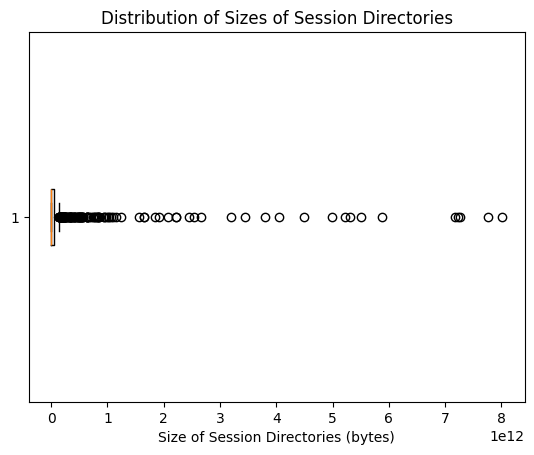

In [97]:
import matplotlib.pyplot as plt
import numpy as np

mean , median = np.mean(list(seshSizes.values()) ), np.median( list(seshSizes.values()))
print( f"Mean: { mean}")
print( f"Median: {  median }")

plt.figure()

plt.boxplot( seshSizes.values(), vert = False)
plt.title( "Distribution of Sizes of Session Directories")
plt.xlabel( "Size of Session Directories (bytes)")

In [ ]:
# Get Years to match sessions
import re
rawXCDir = Path( "../../../data/s3ObjKeys/xchem/raw")

sessionRegex = "^[a-z][a-z][0-9]+-[0-9]+$"

lstWeirdSeshNames = set()

for fragFile in rawXCDir.iterdir():
    if fragFile.is_file():
        print( f"Loading file: {fragFile.name}")
        frag = loadPickle( fragFile)
        keys = frag["Content"][1:]
        for objKey in keys:
            session = objKey.split("/")[2]
            if not re.search( sessionRegex, session):
                lstWeirdSeshNames.add( session )